In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# STEP 2: LOAD THE DATA

import pandas as pd

file_path = '/Users/user/Downloads/uk_house_sales_200.csv'

df = pd.read_excel(
    file_path,
    sheet_name='House Sales Data',
    usecols=['Size_SqFt', 'Price_GBP']
)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df.head())
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Dataset loaded: 200 rows x 2 columns
   Size_SqFt  Price_GBP
0        401     107500
1        421     120000
2        434     116000
3        464     100500
4        495     147000
Memory usage: 0.0 MB


In [3]:
# STEP 3: UNDERSTANDING THE DATA and Rename the Columns 

df = df.rename(columns={
    'Size_SqFt': 'house_size',
    'Price_GBP': 'house_price'
})


In [4]:
# STEP 4: DOING THE QUICK EDA. EDA first = your diagnostic scan. You're the doctor checking the patient before deciding on treatment.

df.head() #what does the data look like


,house_size,house_price
0,401,107500
1,421,120000
2,434,116000
3,464,100500
4,495,147000


In [5]:
# (b) What type of data do I have 

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   house_size   200 non-null    int64
 1   house_price  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [6]:
# (C) describing the data 
df.describe()

,house_size,house_price
count,200.000000,200.000000
mean,1873.300000,355192.500000
std,773.476463,129150.205465
min,401.000000,100500.000000
25%,1244.250000,256125.000000
50%,1884.500000,354000.000000
75%,2536.000000,457250.000000
max,3196.000000,589000.000000


In [7]:
# (D) Are there missing values?

df.isna().sum().sort_values(ascending = False)

house_size     0
house_price    0
dtype: int64

In [8]:
# (E) 

df.duplicated().sum() #tells you → any copy-paste errors?

np.int64(0)

In [9]:
# handle the categorical variable 

# there is none 

In [10]:
# STEP 5:  cleaning step

# from the EDA there is nothing to clean 

In [11]:
# STEP 6: FEATURE ENGINEERING
# With a single feature (house_size) predicting a single target (house_price),
# no additional feature engineering is needed.

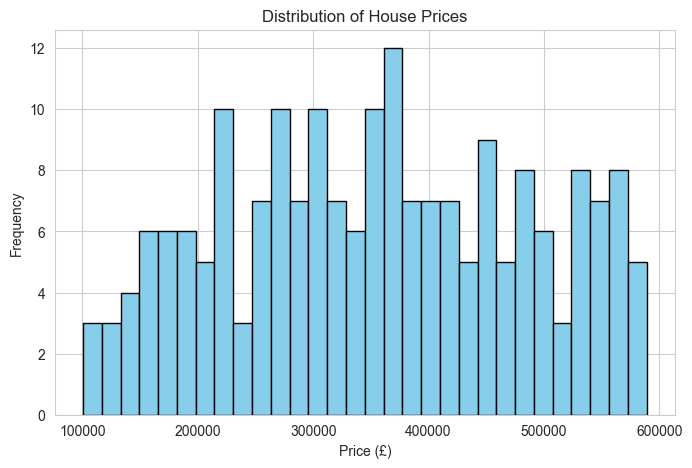

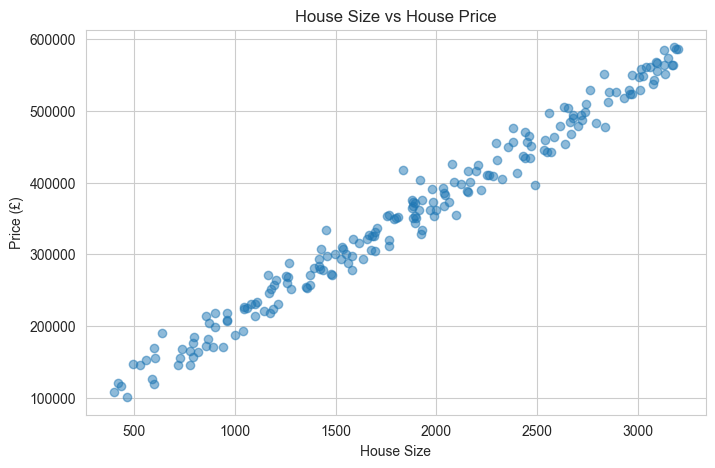

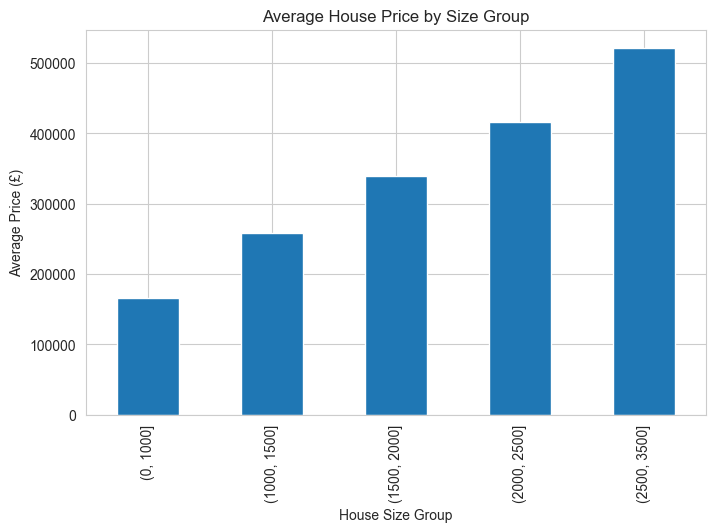

In [12]:
# STEP 7: Deep EDA

sns.set_style("whitegrid")

plot_df = df.sample(min(5000, len(df)), random_state=42)

# Plot 1 — Histogram
plt.figure(figsize=(8, 5))
plt.hist(df['house_price'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.show()

# Plot 2 — Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(plot_df['house_size'], plot_df['house_price'], alpha=0.5)
plt.xlabel('House Size')
plt.ylabel('Price (£)')
plt.title('House Size vs House Price')
plt.show()

# Plot 3 — Bar chart
# Plot 3 — Bar chart
df['size_group'] = pd.cut(df['house_size'], bins=[0, 1000, 1500, 2000, 2500, 3500])

avg_price_by_size = df.groupby('size_group', observed=False)['house_price'].mean()

plt.figure(figsize=(8, 5))
avg_price_by_size.plot(kind='bar')
plt.xlabel('House Size Group')
plt.ylabel('Average Price (£)')
plt.title('Average House Price by Size Group')
plt.show()

In [13]:
# EDA Summary
# - Price distribution is roughly uniform, no extreme skew
# - Scatter plot shows a clear positive linear relationship
# - Average price increases consistently across size groups
# - Conclusion: Linear regression is appropriate for this data

In [15]:
# STEP 9: TRAIN-TEST SPLIT

from sklearn.model_selection import train_test_split

X = df[['house_size']]
y = df['house_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# STEP 10: TRAIN LINEAR REGRESSION WITHOUT SCALING

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
# STEP 11: GET INTERCEPT AND COEFFICIENT

intercept = model.intercept_
coefficient = model.coef_[0]

print("Intercept:", intercept)
print("Coefficient:", coefficient)

Intercept: 47718.81579269044
Coefficient: 164.1903196809646


In [18]:
# STEP 12: EVALUATE MODEL

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 16684.04597518339
RMSE: 22272.308195255173
R²: 0.9646567346478946


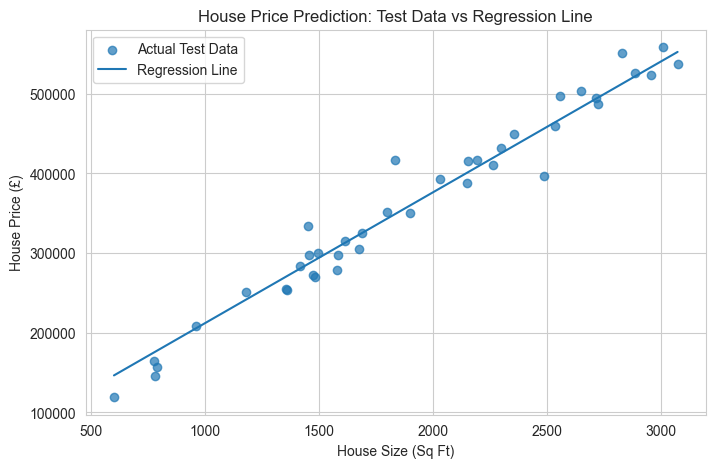

In [19]:
# STEP 12: PLOT TEST DATA + REGRESSION LINE

import matplotlib.pyplot as plt
import pandas as pd

plot_df = X_test.copy()
plot_df['actual_price'] = y_test
plot_df['predicted_price'] = model.predict(X_test)

plot_df = plot_df.sort_values('house_size')

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_df['house_size'],
    plot_df['actual_price'],
    alpha=0.7,
    label='Actual Test Data'
)

plt.plot(
    plot_df['house_size'],
    plot_df['predicted_price'],
    label='Regression Line'
)

plt.xlabel('House Size (Sq Ft)')
plt.ylabel('House Price (£)')
plt.title('House Price Prediction: Test Data vs Regression Line')
plt.legend()

plt.savefig('house_price_regression_test_plot.png', dpi=300, bbox_inches='tight')
plt.show()